# **Bank Telemarketing Dataset -- Client EDA Approach**

#### **Goal :**

#### **Exploratory Analysis: Questions and Visualizations**

Will explore following questions to get indepth to understand about bank clients : 

__Q1 : What is the distribution of client's age, and how does the term deposit subscription conversion rate vary across different age groups?__



In [1]:
## Import commonly used libraries
import pandas as pd 
import numpy as np  
import sidetable
import sklearn
import scipy.stats as stat
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from glob import glob
from itertools import combinations

## Display Setting

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
import warnings
warnings.filterwarnings('ignore')

In [3]:
file = []
data_path = Path.cwd().parent.joinpath("data", "raw")
for f in data_path.glob("*"):
    file.append(f.name)

print(file)

['.gitkeep', 'bank-additional-full.csv', 'bank-additional-names.txt', 'bank-full.csv', 'info.txt']


In [4]:
tele_df = pd.read_csv(data_path.joinpath("bank-additional-full.csv"), sep=';')
tele_df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [5]:
tele_df.shape

(41188, 21)

In [6]:
# Remove whitespaces, ., spaces and lowercase column names
tele_df.columns = tele_df.columns.str.strip().str.replace(".", " ").str.replace(" ", "_").str.lower()
tele_df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp_var_rate', 'cons_price_idx',
       'cons_conf_idx', 'euribor3m', 'nr_employed', 'y'],
      dtype='object')

In [7]:
tele_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp_var_rate    41188 non-null  float64
 16  cons_price_idx  41188 non-null  float64
 17  cons_conf_idx   41188 non-null 

In [8]:
# Check Missing values
import sidetable
miss_df = tele_df.stb.missing()
miss_df.query("percent > 0")

,missing,total,percent


**No Missing Value in give dataset for numeric variables, will explore this.**

**Missing Attribute Values for Categorical Variables:** There are several missing values in some categorical attributes, all coded with the "unknown" label. These missing values can be treated as a possible class label or using deletion or imputation techniques.


**Bank Client Data Description:**

- **age**: Age of the client (numeric)
- **job**: Type of job (categorical: 'admin.', 'blue-collar', 'entrepreneur', 'housemaid', 'management', 'retired', 'self-employed', 'services', 'student', 'technician', 'unemployed', 'unknown')
- **marital**: Marital status (categorical: 'divorced', 'married', 'single', 'unknown')
- **education**: Level of education (categorical: 'basic.4y', 'basic.6y', 'basic.9y', 'high.school', 'illiterate', 'professional.course', 'university.degree', 'unknown')
- **default**: Whether the client has credit in default (binary: 'no', 'yes', 'unknown')
- **housing**: Whether the client has a housing loan (binary: 'no', 'yes', 'unknown')
- **loan**: Whether the client has a personal loan (binary: 'no', 'yes', 'unknown')


## **Formatting and Consistency Check**

In [9]:
dtype_df = pd.DataFrame({
    'dtype': tele_df.dtypes,
    'nunique': tele_df.nunique(),
    'unique' : [tele_df[col].unique() for col in tele_df.columns]
}, index=tele_df.columns)
dtype_df

,dtype,nunique,unique
age,int64,78,"[56, 57, 37, 40, 45, 59, 41, 24, 25, 29, 35, 5..."
job,object,12,"[housemaid, services, admin., blue-collar, tec..."
marital,object,4,"[married, single, divorced, unknown]"
education,object,8,"[basic.4y, high.school, basic.6y, basic.9y, pr..."
default,object,3,"[no, unknown, yes]"
housing,object,3,"[no, yes, unknown]"
loan,object,3,"[no, yes, unknown]"
contact,object,2,"[telephone, cellular]"
month,object,10,"[may, jun, jul, aug, oct, nov, dec, mar, apr, ..."
day_of_week,object,5,"[mon, tue, wed, thu, fri]"


# **Exploratory Data Analysis ---- bank client attributes**

**Target Variable**

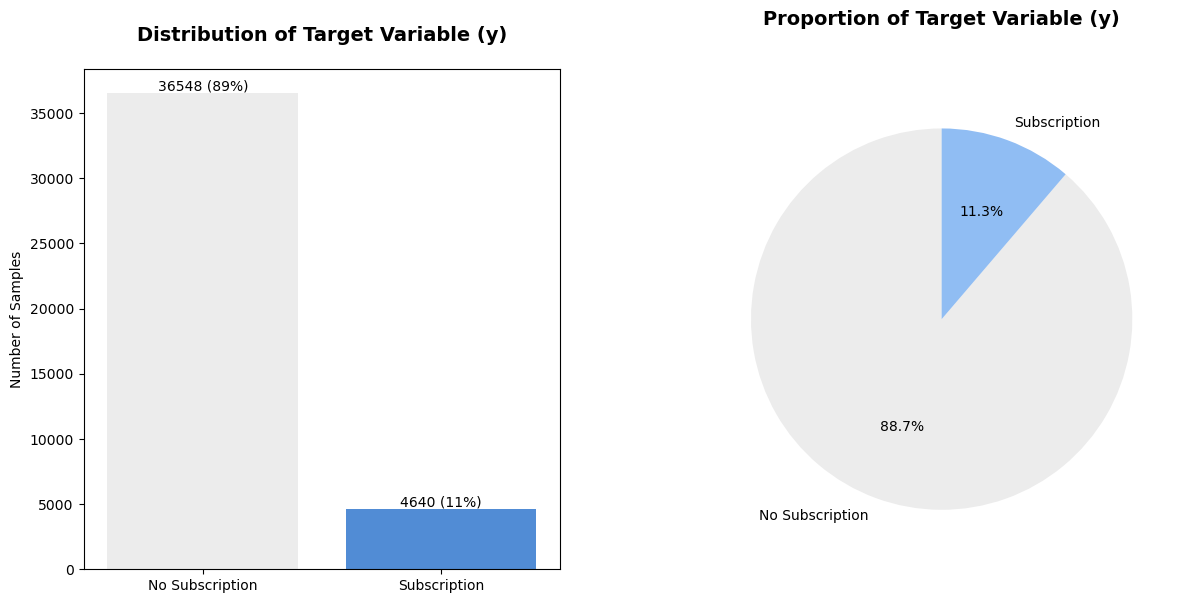

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
# Countplot for target variable
sns.countplot(
    data=tele_df, x='y', 
    order=tele_df['y'].value_counts().index, 
    palette = ['#ececec', '#3B8AEB90'],
    ax=ax[0])

ax[0].set_title('Distribution of Target Variable (y)', fontsize=14, fontweight='bold', y=1.04)
ax[0].set_xlabel('')
ax[0].set_ylabel('Number of Samples')
ax[0].set_xticks([0, 1], labels = ['No Subscription', 'Subscription'], rotation=0)

# Add percentage labels on bars
for i, v in enumerate(tele_df['y'].value_counts()):
    percentage = 100 * v / len(tele_df)
    ax[0].text(i, v + 200, f"{v} ({percentage:.0f}%)", ha='center', fontsize=10)

# Pie chart for target variable
tele_df['y'].value_counts().plot.pie(
    autopct='%1.1f%%', 
    colors = ['#ececec', "#3B8AEB90"], 
    startangle=90, labels = ['No Subscription', 'Subscription'],
    ax=ax[1])

ax[1].set_ylabel('')
ax[1].set_title('Proportion of Target Variable (y)', fontsize=14, fontweight='bold', y=1.10)

# Add layout adjustments
plt.tight_layout()
plt.subplots_adjust(wspace=0.3, hspace=0.3)
plt.show()

**Data is highly imbalanced, with a significant majority of customers not subscribing to the term deposit. This imbalance will need to be addressed in the modeling phase, possibly through techniques such as resampling or using algorithms that can handle class imbalance effectively.**

In [11]:
# Make y binary in next step:
tele_df['y_binary'] = tele_df['y'].map({'yes': 1, 'no':0})

### **Dimension Analysis**

In [12]:
tele_df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp_var_rate', 'cons_price_idx',
       'cons_conf_idx', 'euribor3m', 'nr_employed', 'y', 'y_binary'],
      dtype='object')

In [13]:
## dimensions to be focus for eda
cols = ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'y', 'y_binary']
client_df = tele_df[cols]

**Metric : Conversion Rate**

How to calculate : Conversion rate compute by total number of term deposit subscribers/ Total number of contact. 
   - **Conversion rate** highlights the __most effective target group__ (best response rate) and __Which group is easiest to convince and highly responsive?__
   - Conversion rate shows where efficieny lies.


#### **What to do:**
    - User defined function for 
        - univariate analysis of variables to compute total counts of contact of each categories and their respective conversion rate.
        - bivariate analysis of variables with another variables for total counts and conversion rate for hidden pattern and trend.
        - Cumulative sum of total contacts and yes responses of variable's categories.
        - statistical test for association between categorical variable and y (term-deposit)
    - compute year column as given dataset is ordered in may 2008 to nov 2010.
    - orderd month as natural order of months.


In [14]:
# Reorder months as per natural order
months = ['mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']
tele_df['months_order'] = pd.Categorical(tele_df['month'], categories=months, ordered=True)


In [15]:
# Here we just get an insight of how months are going one by one in the dataset.
# Just a remainder: the observations are ordered by date (from May 2008 to November 2010.
months_arr = [
    [i, m]
    for i, m in enumerate(tele_df['month'])
    if i==0 or m != tele_df['month'].iloc[i-1]    ## “Take this row if it’s the first row OR if the month changed compared to the previous row.”
]
months_arr = np.array(months_arr)


__We've got :__

__2008 : [0, 27690)__

__2009 : [27690, 39130)__

__2010 : [39130, 41188)__



In [16]:
tele_df['year'] = np.hstack((np.array([2008] * (27690 - 0)),
           np.array([2009] * (39130 - 27690)),
           np.array([2010] * (41188 - 39130))))

In [17]:
import sys
sys.path.append("..")
from src import my_file

#### **Let's explore the questions that were outlined in the goal section**

### __Dimension Analysis__

__Analyzing distribution of dimensions and YES-proportion__

**Dimension : `job`**

__Grouping__: Aggregate data by job role.

__Calculation__:Compute the conversion rate (percentage of “yes”) per job.

__Visualization__: An interactive bar chart shows the rates with annotations highlighting top roles.



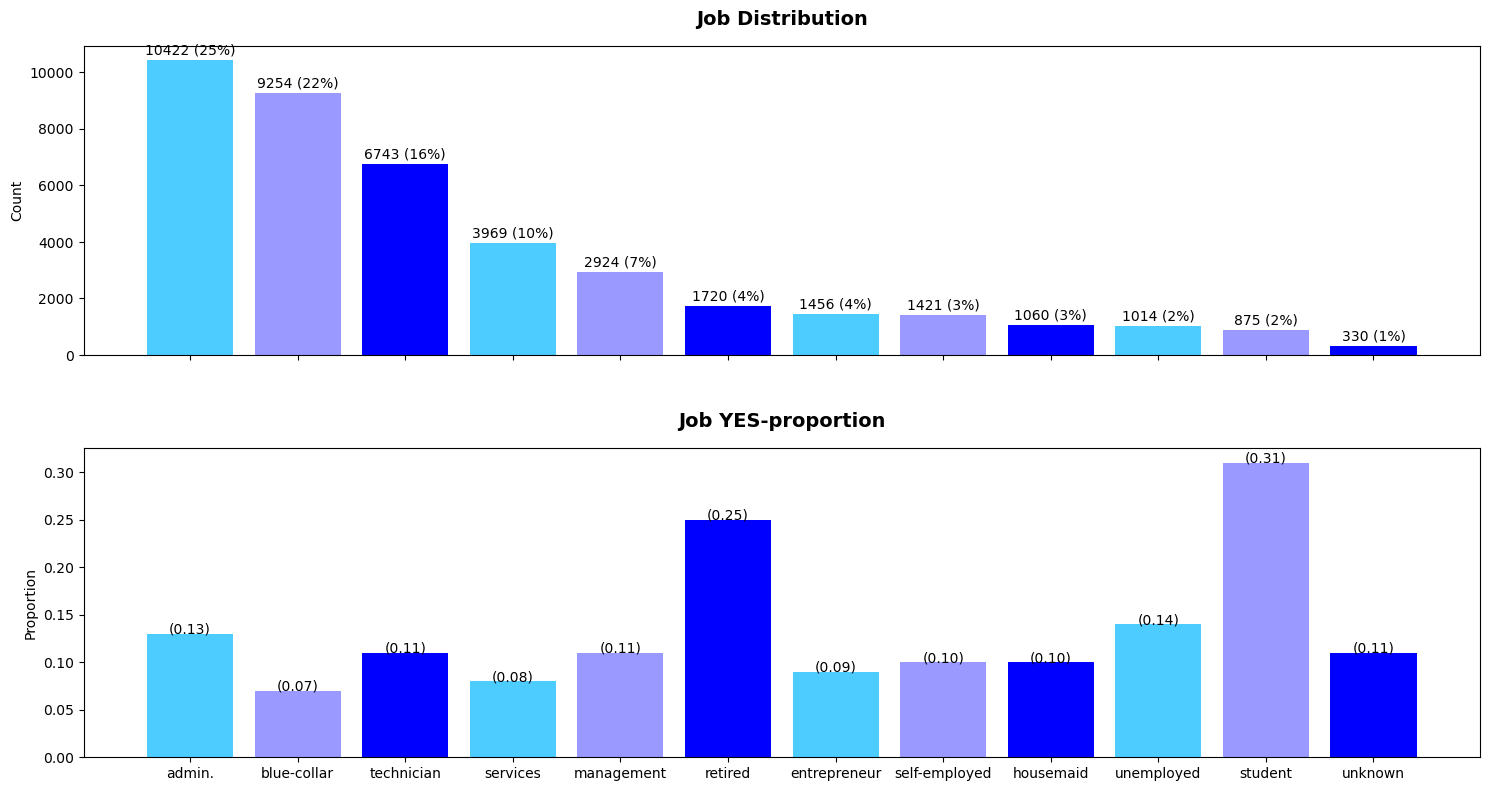

In [18]:
job_count, fig = my_file.plot_univariate_analysis_categorical_var(tele_df, 'job', 'y', 'Job')


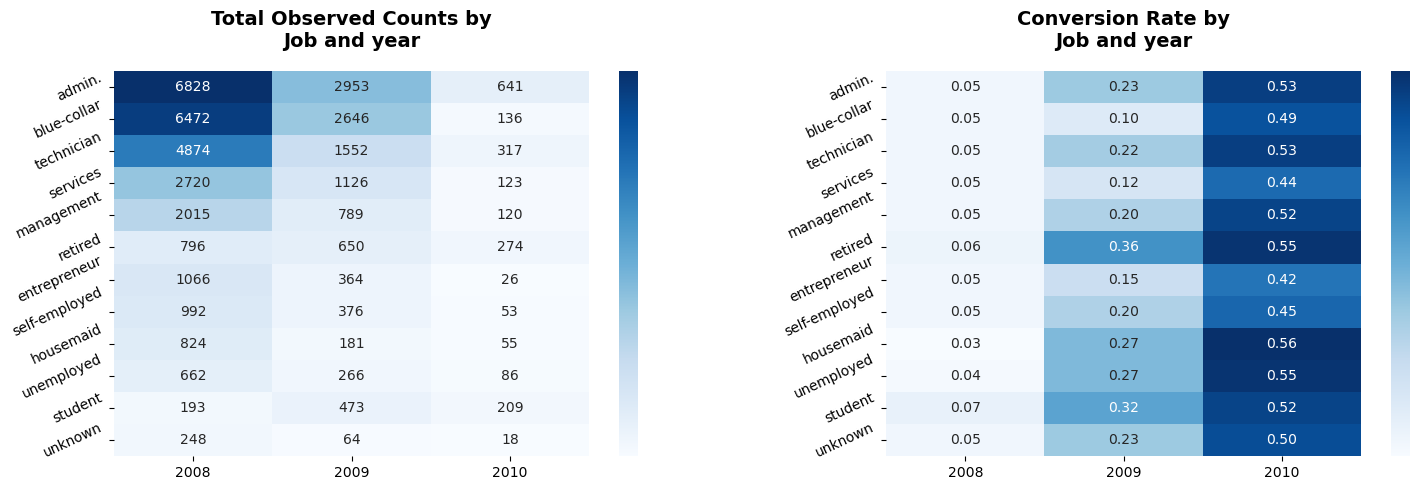

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
my_file.plot_heatmap_bivariate_analysis(tele_df, 'job', 'year', 'y_binary',fig, ax);

From the job YES-proportion plot we observed that **student and retired** are more likely to agree to subscribe for a term deposit, but considering heatmap plot we can see that this pattern works only for year 2009.
It also works for year 2008 but much less and this pattern disappears for year 2010. So, we can't confident about such patterns.

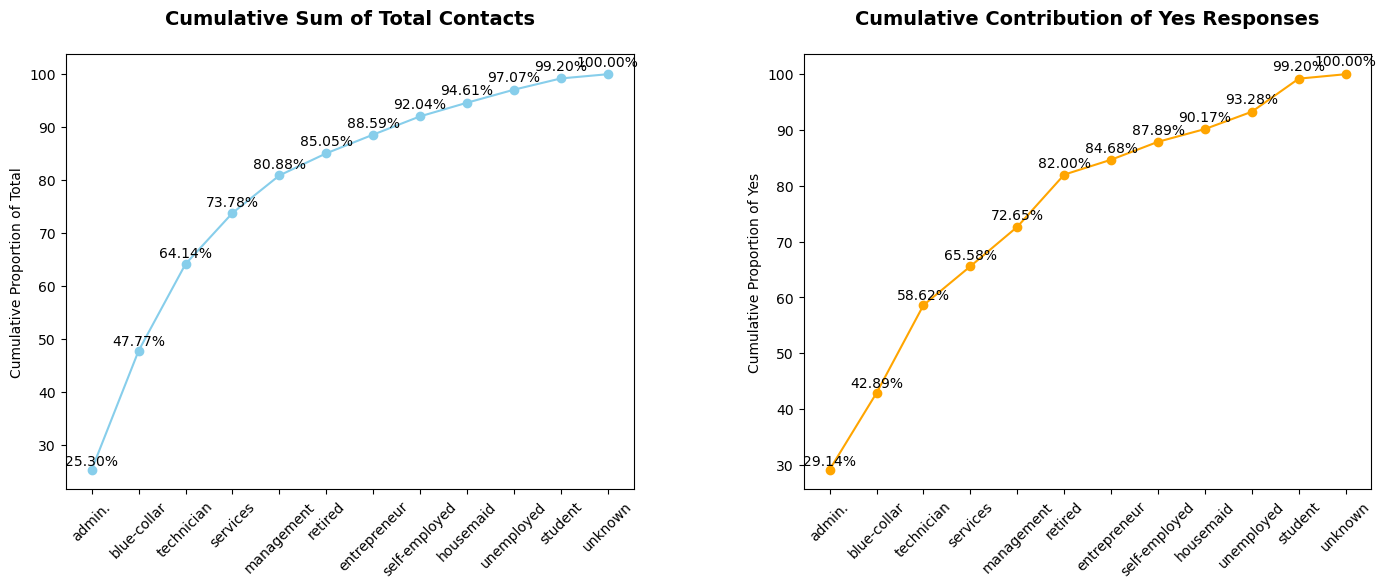

In [20]:
# Cumulative sum of total counts and yes response by job category
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
my_file.plot_cumsum_total_yes_response(job_count, 'job', 'cumsum_total_proportion', 'cumsum_yes_proportion', fig=fig, ax=ax);

In [21]:
# Statistical test between job and y(term-deposit)
df = my_file.chi_square_categorical_y(tele_df, 'job', 'y')
df

,statistical_values
Chi-square,961.24244
pvalue,0.0
cramers_v,0.152768
effect_size,medium


- association between job and y is **medium**.

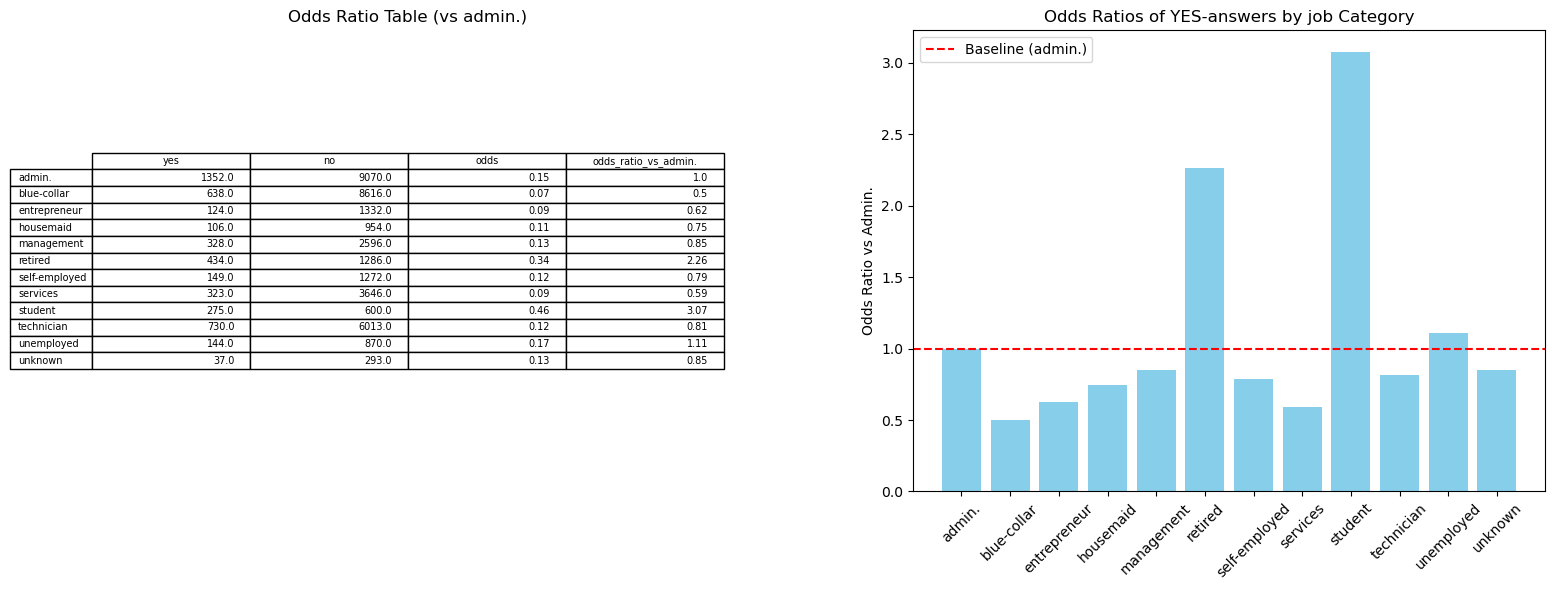

In [22]:
my_file.plot_odd_ratio_table(tele_df, 'job', 'y', 'admin.')

- **Student, retired and unemployed more likely to subscribe compared to admin. workers**

**Conclusion :**

- Most of the people in the dataset are from working class(admin + blue-collar-technician + services ~ 73%).
- Yes-proportion in the dataset hold by this working class ~ 66%.
- job type influences subscription, but the strength of the relationship is **medium**.

**Dimension : `Marital`**

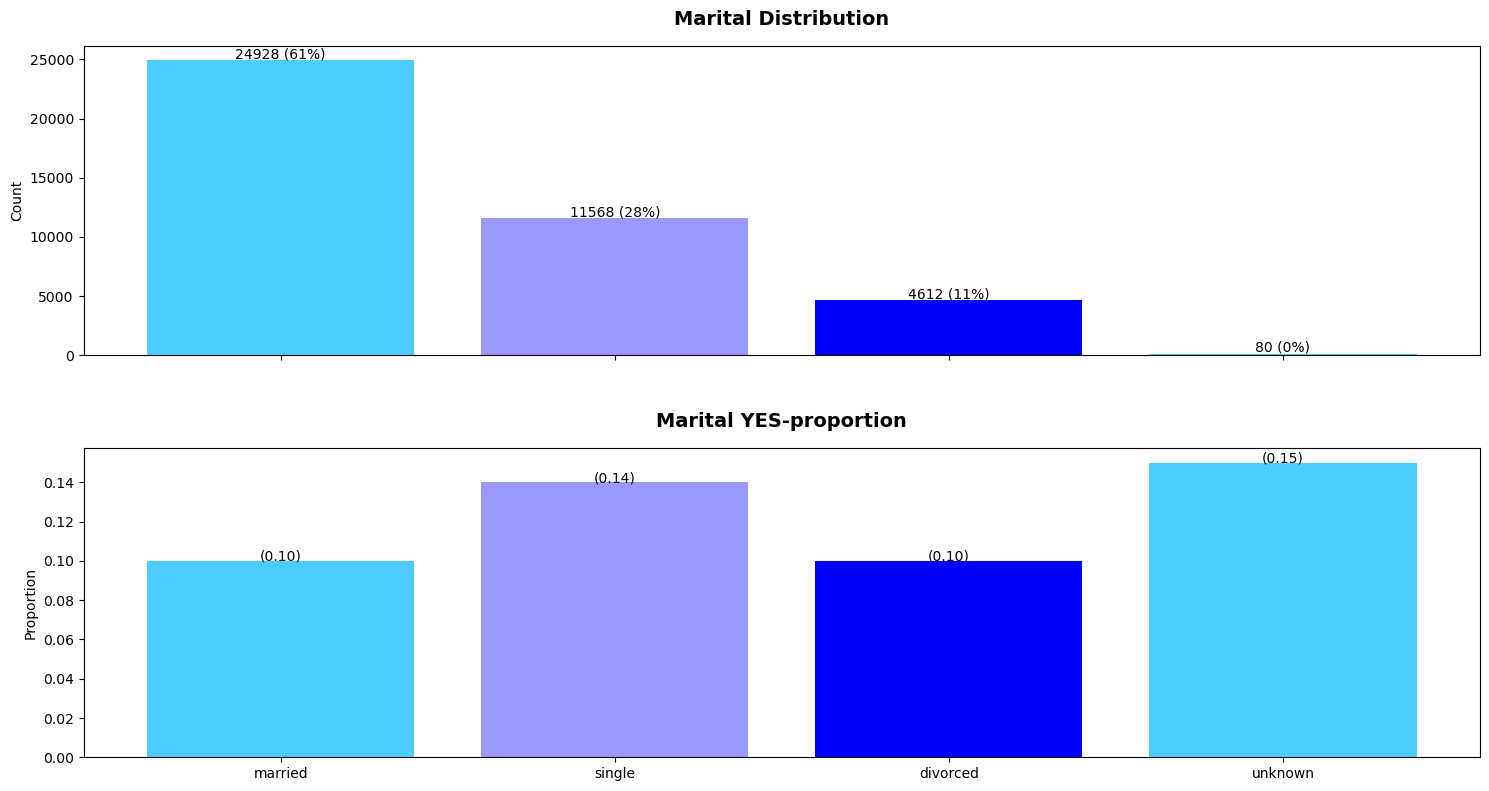

In [23]:
marital_counts, fig = my_file.plot_univariate_analysis_categorical_var(tele_df, 'marital', 'y', 'Marital')

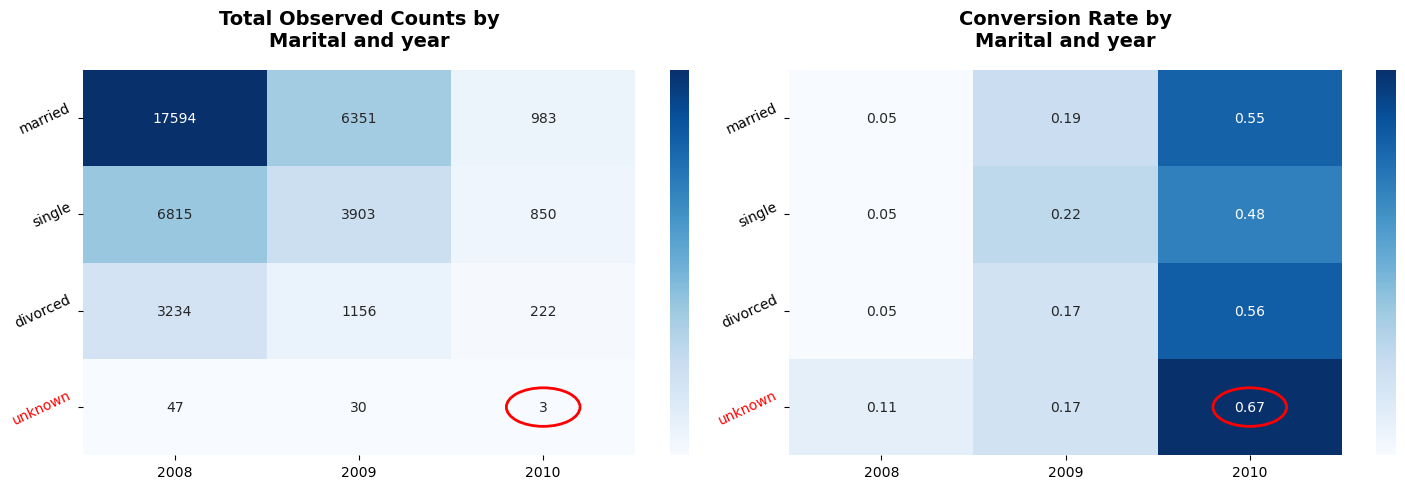

In [24]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
my_file.plot_heatmap_bivariate_analysis(tele_df, 'marital', 'year', 'y_binary', fig, ax)

ax[0].add_artist(plt.Circle(xy=(2.5, 3.5), radius=0.2, color='red', fill=False, lw=2))
ax[1].add_artist(plt.Circle(xy=(2.5, 3.5), radius=0.2, color='red', fill=False, lw=2))

for tick1, tick2 in zip(ax[0].get_yticklabels(), ax[1].get_yticklabels()):
    if tick1.get_text() == 'unknown':
        tick1.set_color('red')
    if tick2.get_text() == 'unknown':
        tick2.set_color('red')

plt.tight_layout()
plt.show()


- `Single` client look like tend to subscribe more than other category(based on the barplot or first plot) but this trend don't follow on the YES-proportion by year(heatmap plot).
- As to `unknown` category, we don't sufficient data to rely on this trend/pattern.

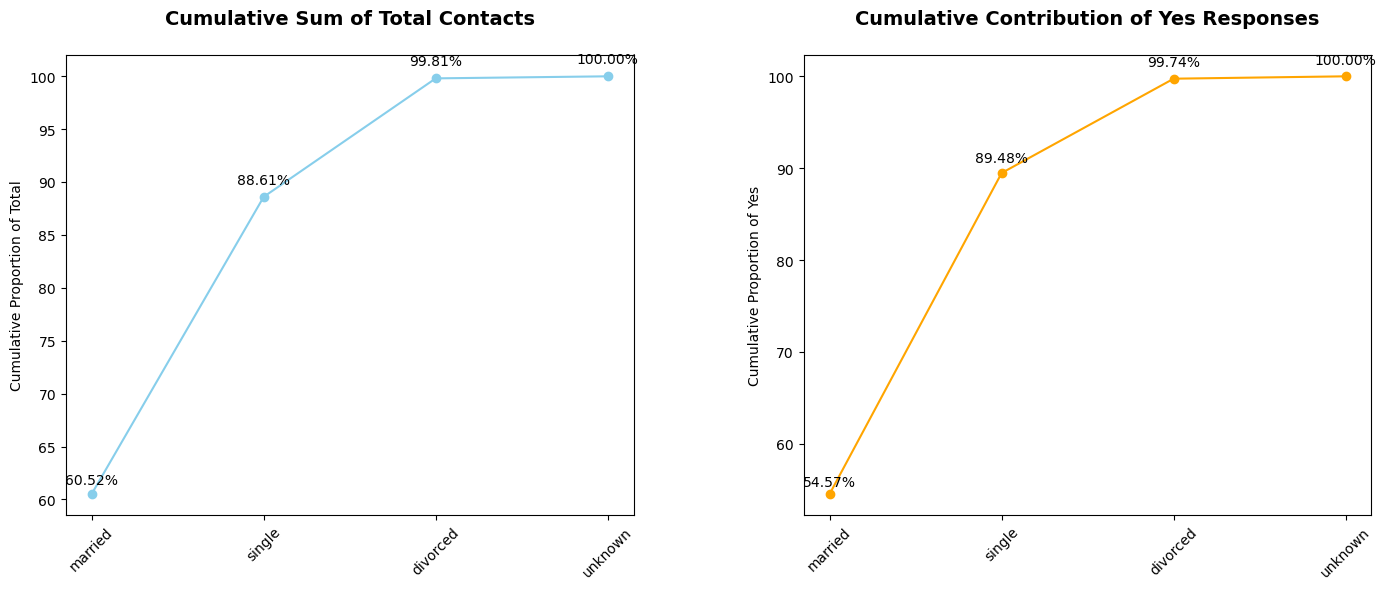

In [25]:
# Cumulative sum of total counts and yes response by marital 
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
my_file.plot_cumsum_total_yes_response(marital_counts, 'marital', 'cumsum_total_proportion', 'cumsum_yes_proportion', fig=fig, ax=ax);


In [26]:
my_file.chi_square_categorical_y(tele_df, 'marital', 'y')

,statistical_values
Chi-square,122.655152
pvalue,0.0
cramers_v,0.05457
effect_size,small


- association between marital and y is **small**.

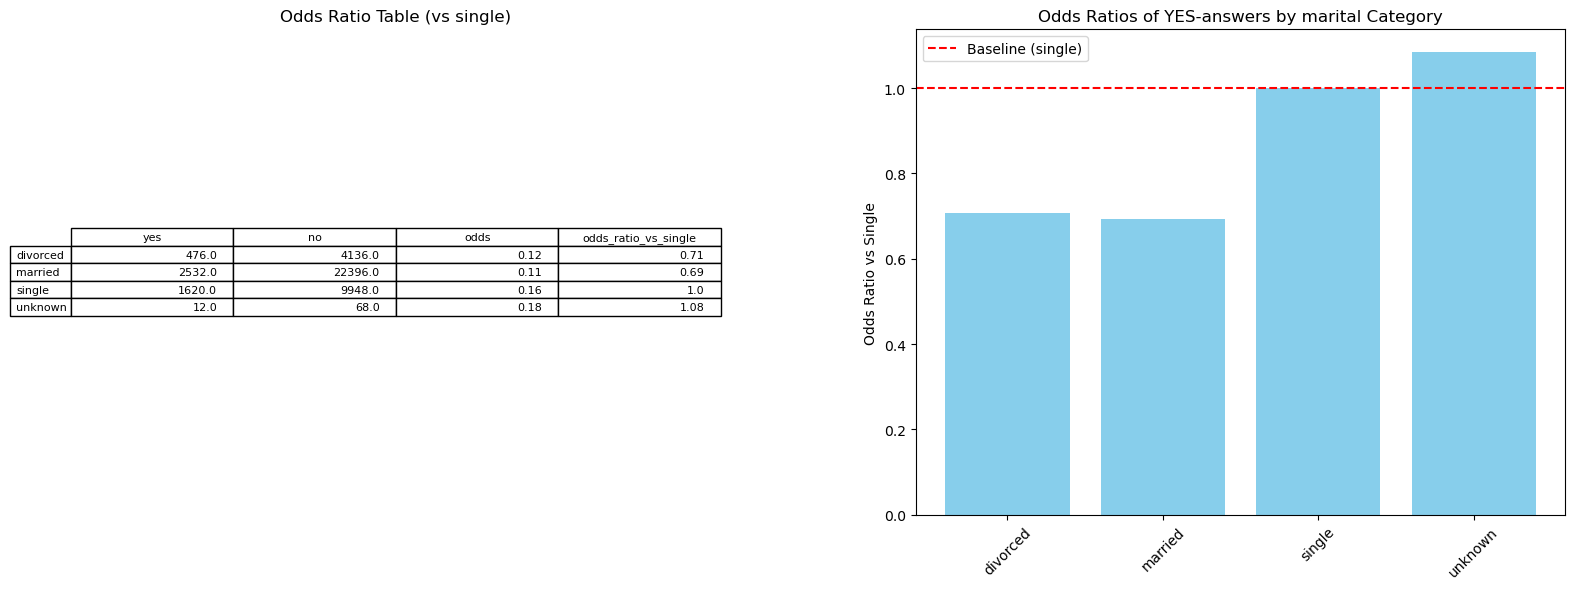

In [27]:
my_file.plot_odd_ratio_table(tele_df, 'marital', 'y', 'single')

- **Unknown client more likely to subscribe compared to single but we don't rely upon this claim bcoz we unknown category don't have enough data.**

**Conclusion :**

- Most client in the dataset are married(~ 60%).
- Yes-proportion in the dataset hold by married client(~ 55%).
- marital type influence on subscription for term deposit is **negligible**.

**Dimension : `Education`**

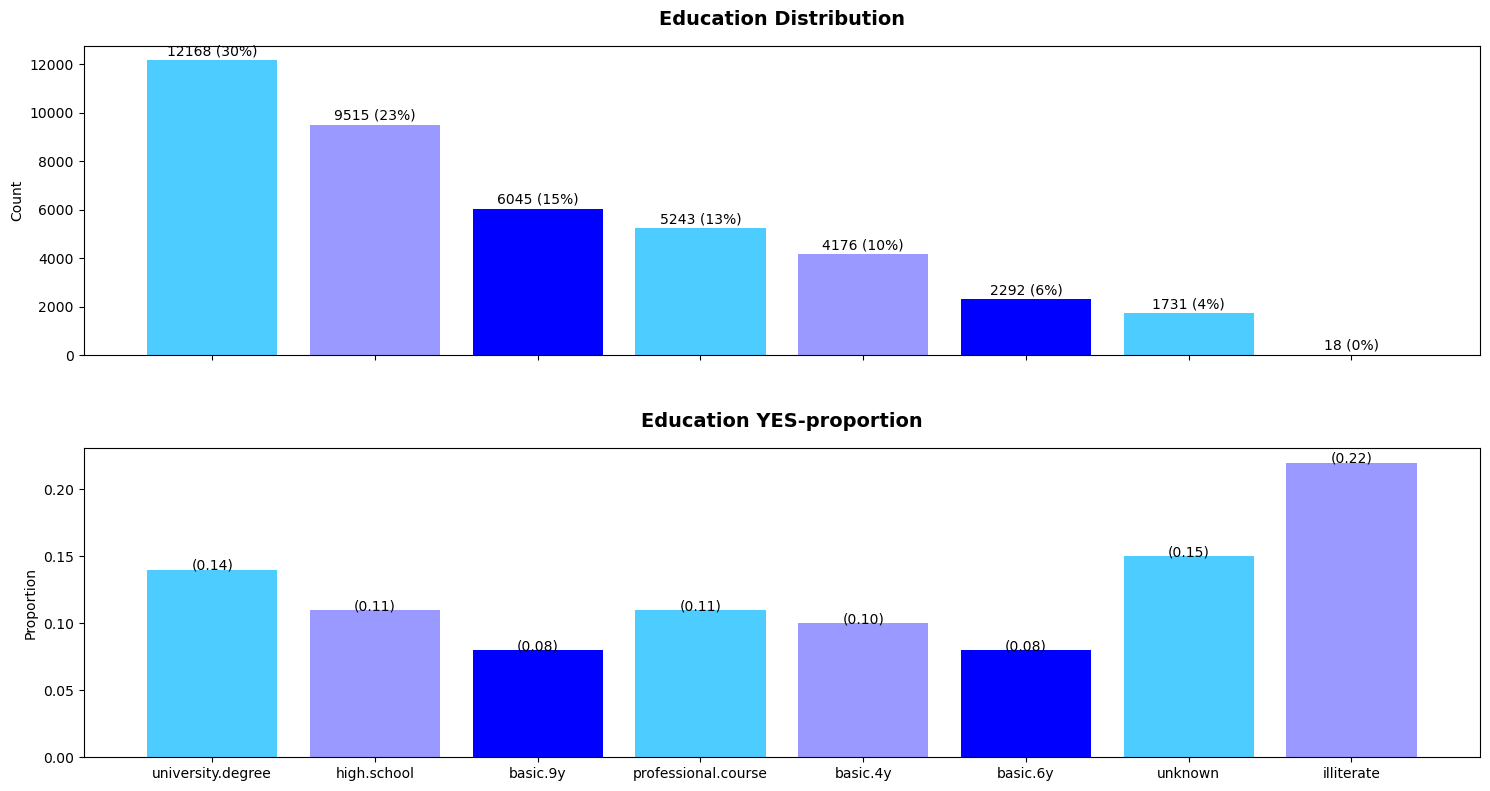

In [28]:
education_counts, fig = my_file.plot_univariate_analysis_categorical_var(tele_df, 'education', 'y', 'Education')


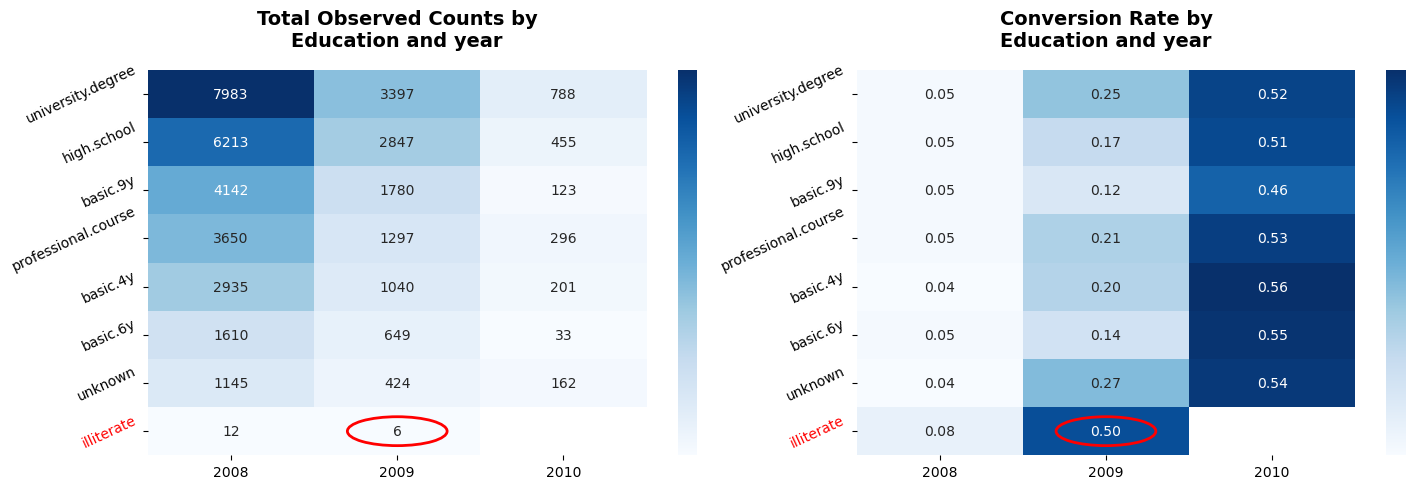

In [29]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
my_file.plot_heatmap_bivariate_analysis(tele_df, 'education', 'year', 'y_binary',fig, ax)

ax[0].add_patch(plt.Circle(xy=(1.5, 7.5), radius=0.3, fill=False, color='r', lw=2))
ax[1].add_patch(plt.Circle(xy=(1.5, 7.5), radius=0.3, fill=False, color='r', lw=2))

for tick1, tick2 in zip(ax[0].get_yticklabels(), ax[1].get_yticklabels()):
    
    if tick1.get_text() == 'illiterate':
        tick1.set_color('red')
        
    if tick2.get_text() == 'illiterate':
        tick2.set_color('red')

plt.tight_layout();


- `Illiterate` client more like to subscribe(in first plot) but donot have sufficient data to hold this claim(in heatmap plot) and 6 observation of 2009 with Yes-proportion of 0.50 seems like a kind of anamoly here.
- Other category of education donot follow any trend by year.

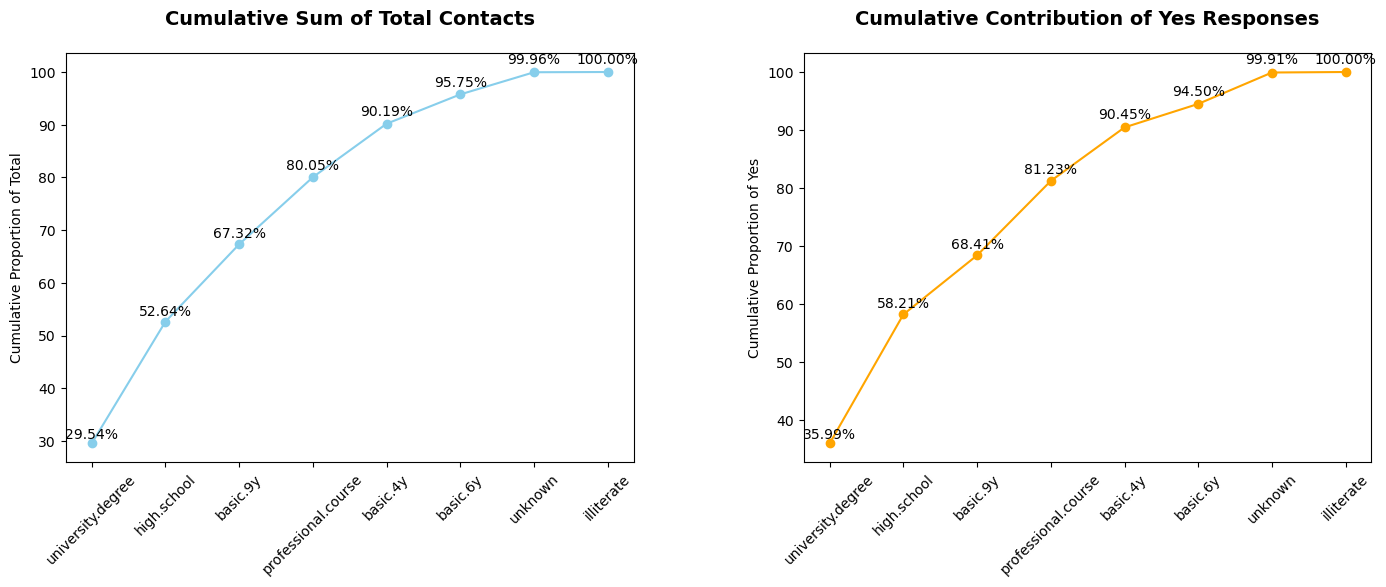

In [30]:
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
my_file.plot_cumsum_total_yes_response(education_counts, 'education', 'cumsum_total_proportion', 'cumsum_yes_proportion', fig=fig, ax=ax);

In [31]:
my_file.chi_square_categorical_y(tele_df, 'education', 'y')

,statistical_values
Chi-square,193.105905
pvalue,0.0
cramers_v,0.068472
effect_size,small


- Association between education and y(term-deposit) is small.

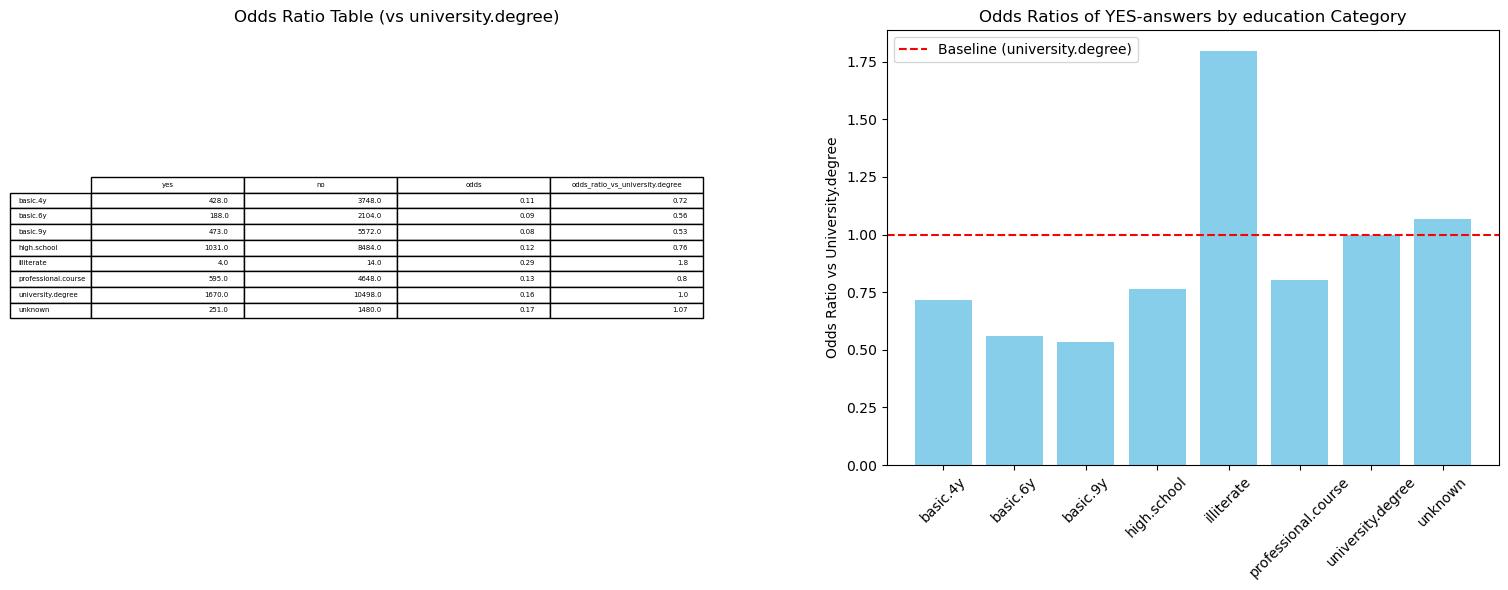

In [32]:
my_file.plot_odd_ratio_table(tele_df, 'education', 'y', 'university.degree');

- **Unknown and illiterate clients more likely to subscribe compared to university.degree but we don't rely upon this claim bcoz illiterate category not have sufficient data.**

**Conclusion :**

- There is no substantial evidence of relationships between education's categories and YES-answers.

**Dimension : `Default`**

`default`: has credit in default? (categorical: 'no', 'yes', 'unknown')

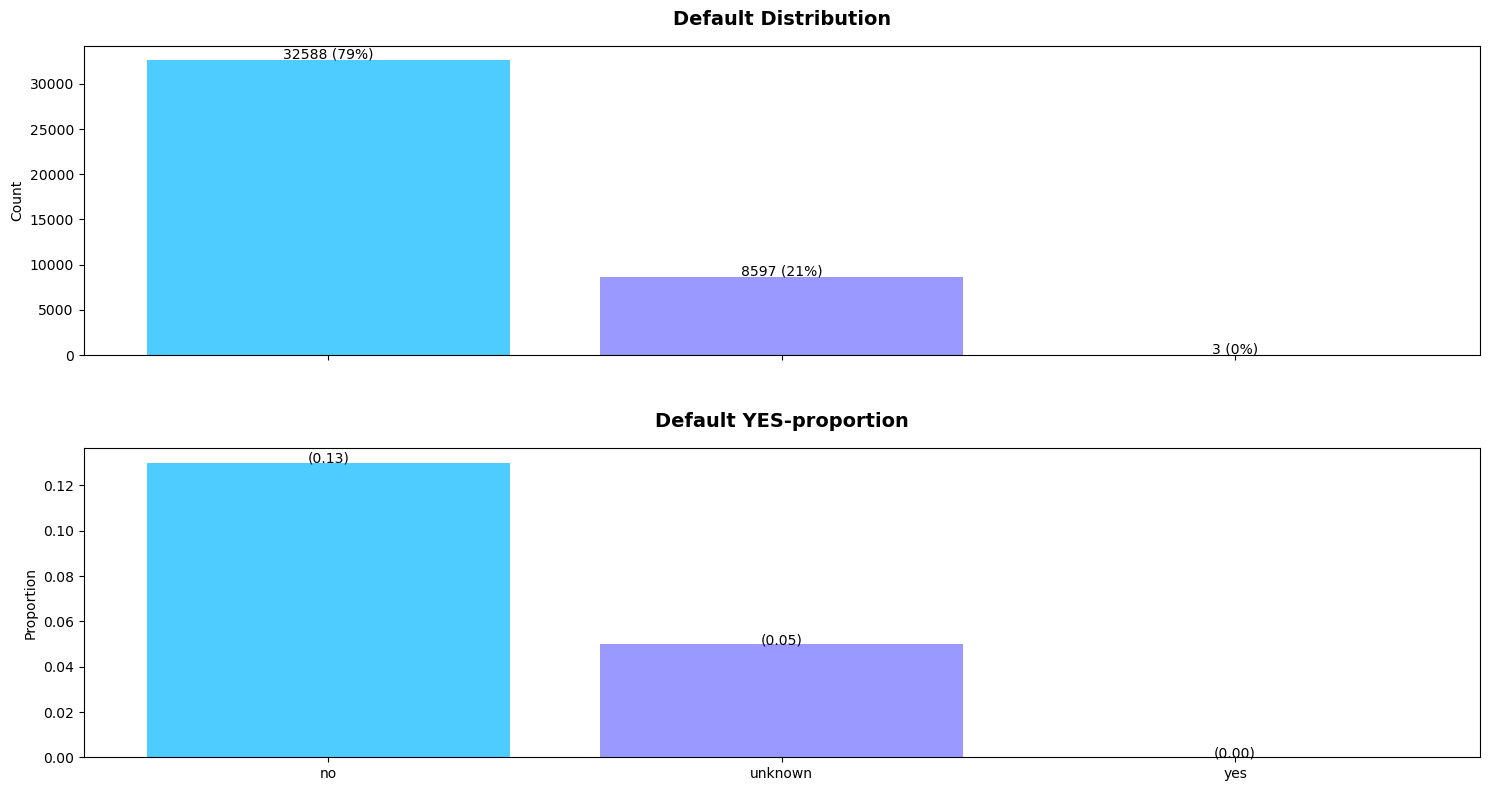

In [33]:
default_counts, fig = my_file.plot_univariate_analysis_categorical_var(tele_df, 'default', 'y', 'Default')

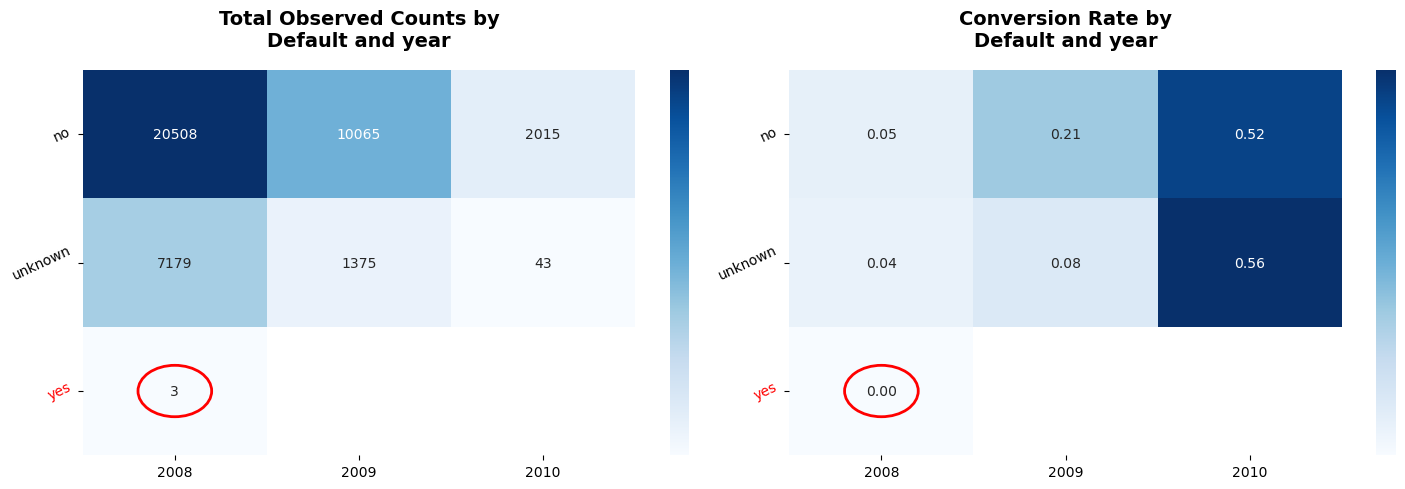

In [34]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
my_file.plot_heatmap_bivariate_analysis(tele_df, 'default', 'year', 'y_binary', fig, ax)

ax[0].add_patch(plt.Circle(xy=(0.5, 2.5), radius=0.2, fill=False, color='r', lw=2))
ax[1].add_patch(plt.Circle(xy=(0.5, 2.5), radius=0.2, fill=False, color='r', lw=2))

for tick1, tick2 in zip(ax[0].get_yticklabels(), ax[1].get_yticklabels()):
    if tick1.get_text() == 'yes':
        tick1.set_color('red')
    if tick2.get_text() == 'yes':
        tick2.set_color('red')

plt.tight_layout()
plt.show()

- Client with `no credit` default category look like tend to subscribe more than other category(based on barplot or first plot), but it's due to 2009 result(heatmap plot). Don't see any significance difference in 2008 and 2010.
- 3 observation of 2008 and yes-proportion 0.0 seems like a kind of anomaly here.

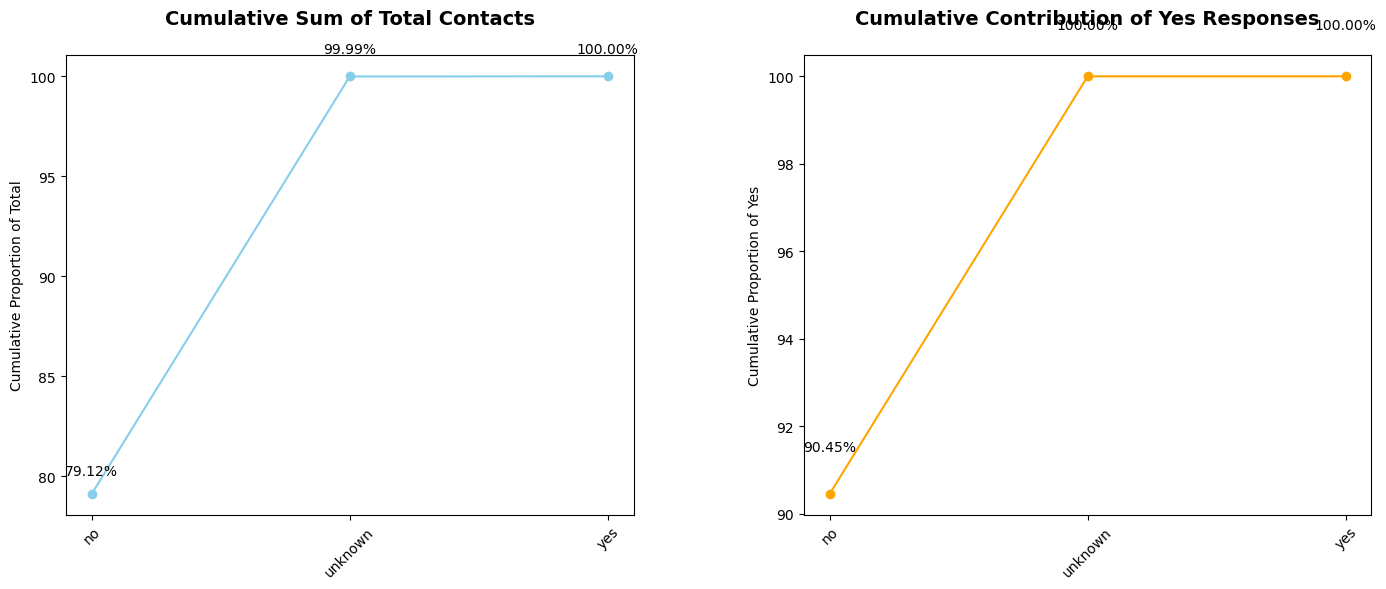

In [35]:
# cumsum of total counts and yes response by default
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
my_file.plot_cumsum_total_yes_response(default_counts, 'default', 'cumsum_total_proportion', 'cumsum_yes_proportion', fig=fig, ax=ax);

In [36]:
# chi-square test between default and y(term-deposit)
my_file.chi_square_categorical_y(tele_df, 'default', 'y')

,statistical_values
Chi-square,406.577515
pvalue,0.0
cramers_v,0.099354
effect_size,small


- **Association between default and y is negligible.**

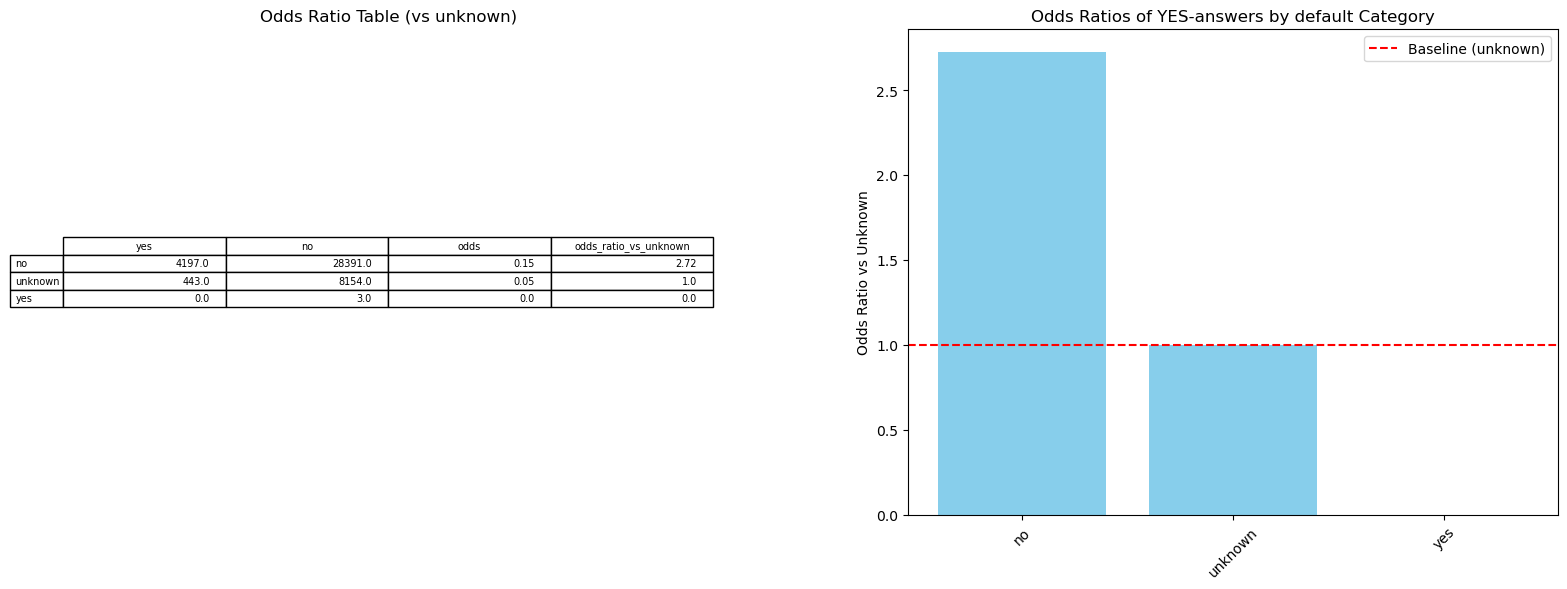

In [37]:
my_file.plot_odd_ratio_table(tele_df, 'default', 'y', 'unknown')

- **no credit default category client more likely to subscribe compared to unknown credit history.**

**Conclusion :**

- During campaign client with no default history contacted(~ 79%) than default history(3 count only in year 2008).
- No substantial evidence of relationship between default's categories and YES-responses.

**Dimension : `housing`**

housing : has housing loan? (categorical : 'no', 'yes', 'unknown')

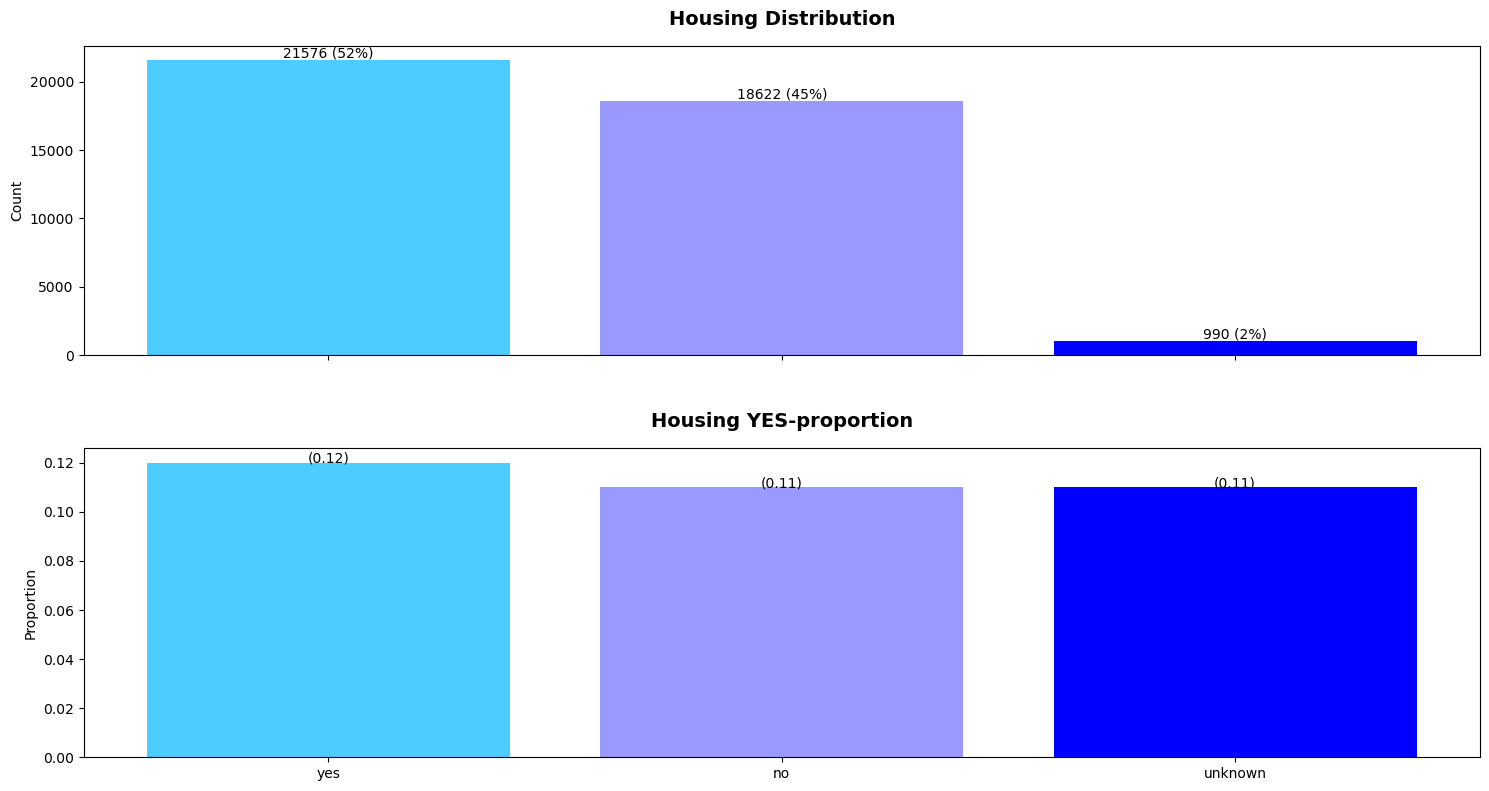

In [38]:
house_counts, fig = my_file.plot_univariate_analysis_categorical_var(tele_df, 'housing', 'y', 'Housing')

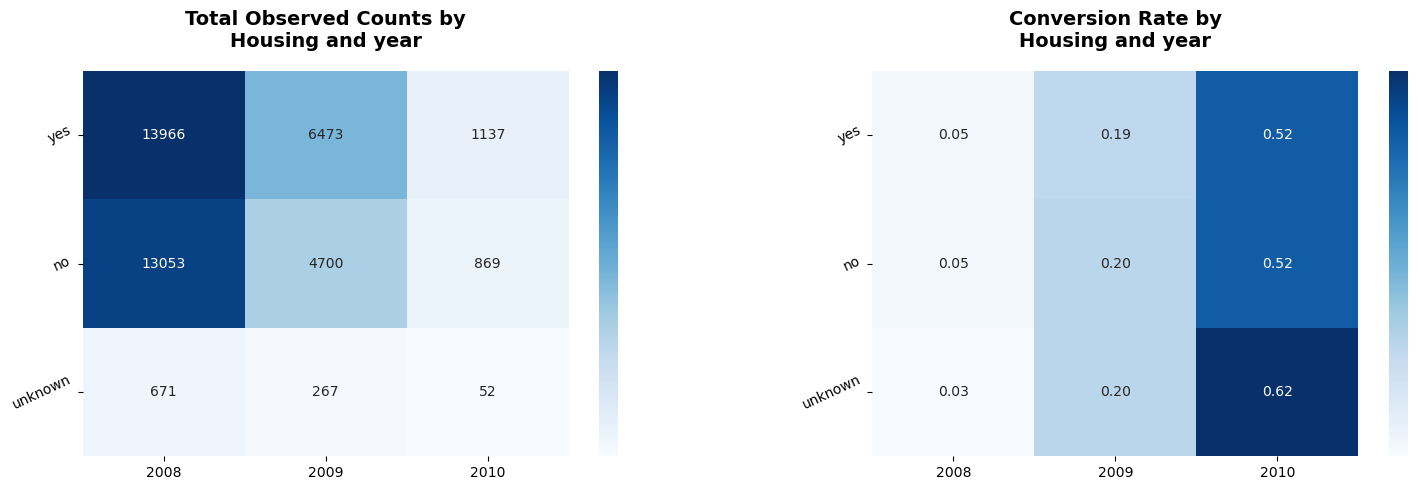

In [39]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
my_file.plot_heatmap_bivariate_analysis(tele_df, 'housing', 'year', 'y_binary', fig=fig, ax=ax);

- client with housing loan more likely to subscribe than other category(based on yes-proportion plot or first plot) but this trend don't follow on the YES-proportion by year(heatmap).

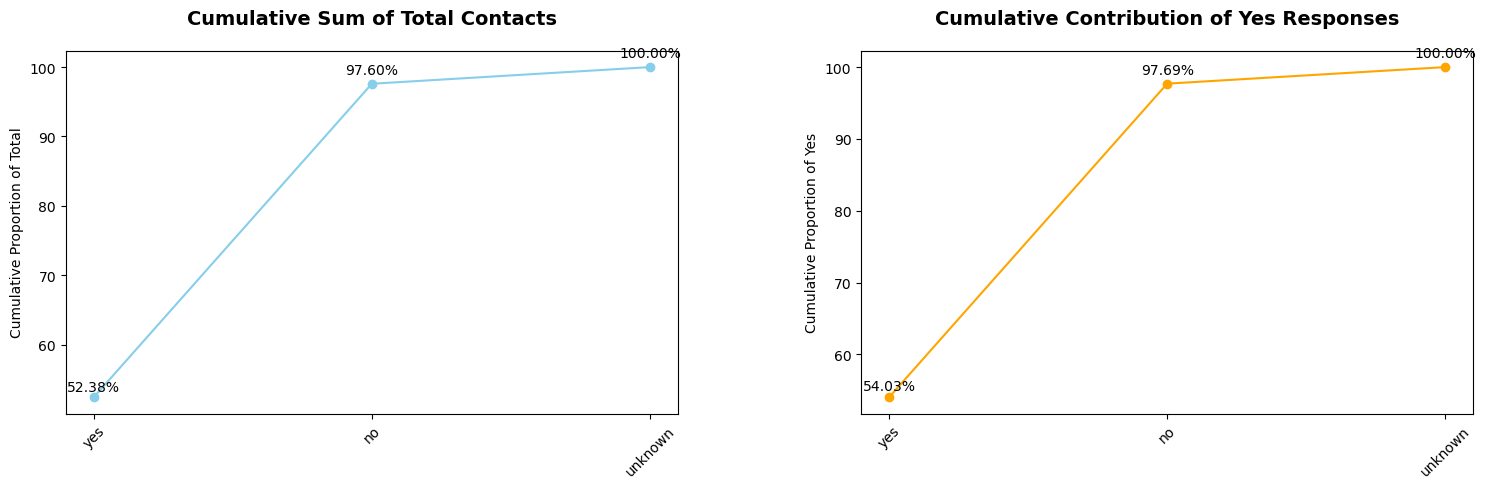

In [40]:
# cumsum of total counts and yes proportion by housing loan
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
my_file.plot_cumsum_total_yes_response(house_counts, 'housing', 'cumsum_total_proportion', 'cumsum_yes_proportion', fig=fig, ax=ax);

In [41]:
# Chi-square test between housing and y(term-deposit)
my_file.chi_square_categorical_y(tele_df, 'housing', 'y')

,statistical_values
Chi-square,5.684496
pvalue,0.058294
cramers_v,0.011748
effect_size,small


- **Association between housing loan and y(term-deposit) is negligible.**

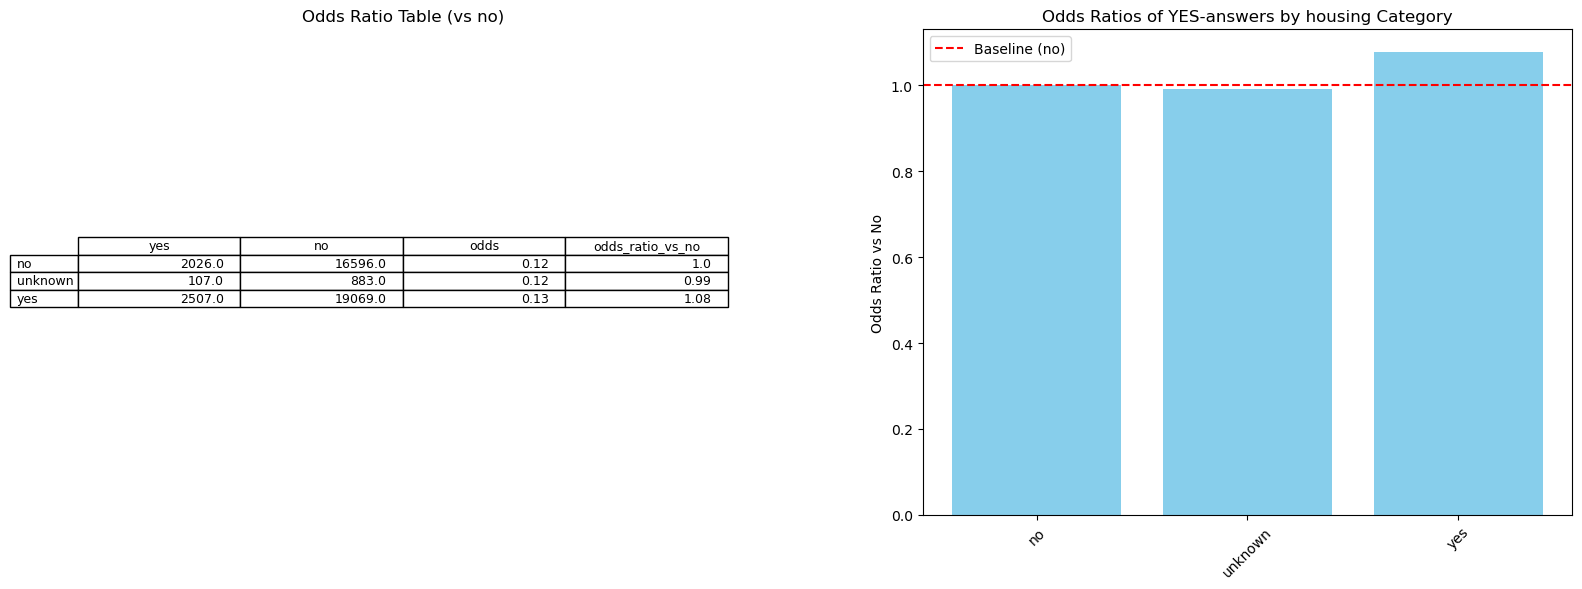

In [42]:
my_file.plot_odd_ratio_table(tele_df, 'housing', 'y', 'no')

- **Client with housing loan more likely to subscribe compared to no housing loan.**

**Conclusion :**
- During the campaign, clients with housing loans (~ 52%) were contacted more frequently than those without housing loans (~ 45%). This suggests that the bank already had easier access to housing loan clients prior to the campaign, making them a more readily reachable group compared to other categories.
- No substantial evidence of relationship between housing's categories and YES-responses. 

**Dimension : `loan`**

`loan` : has personal loan? (categories : 'no', 'yes', 'unknown')

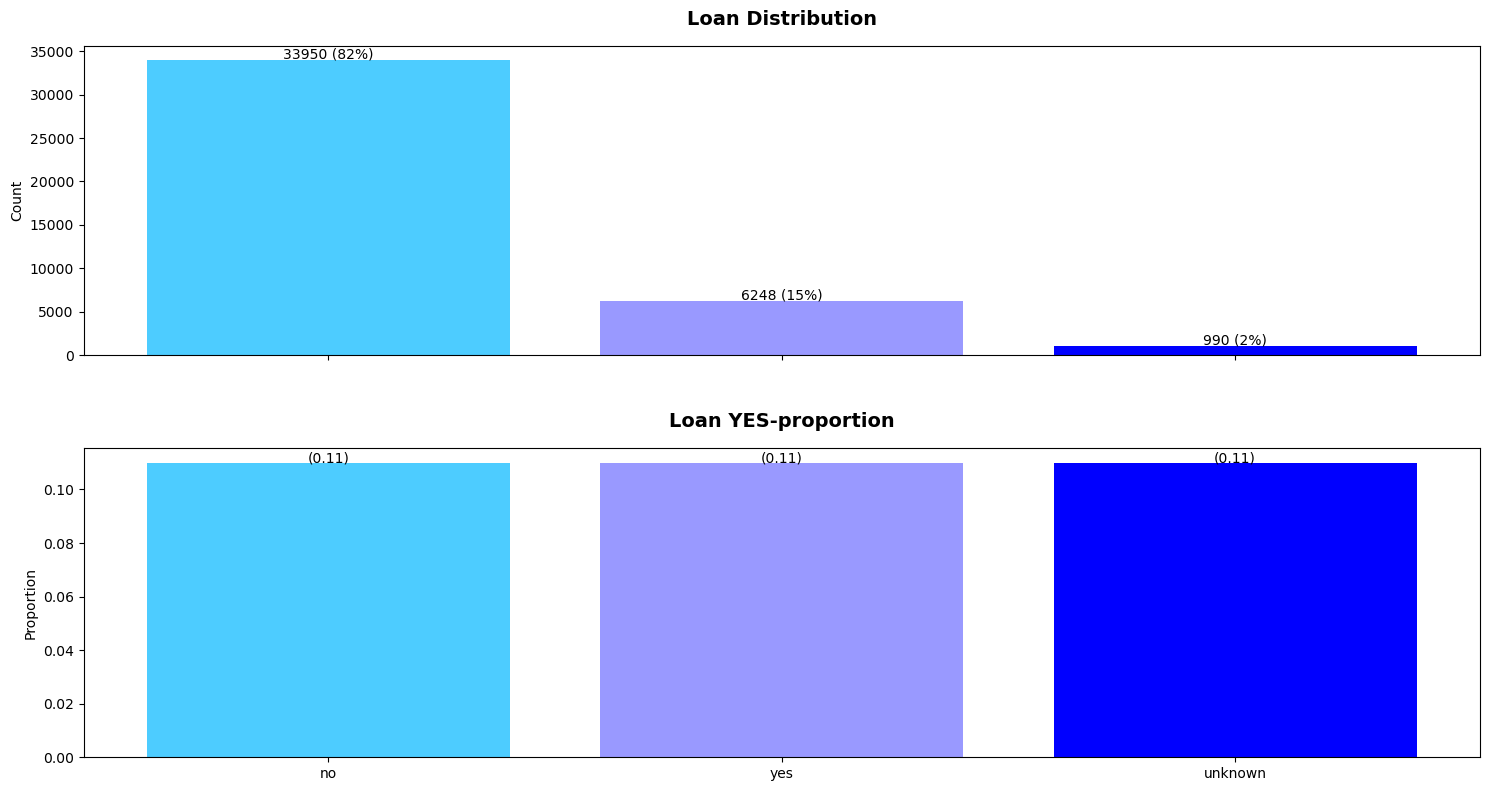

In [43]:
loan_counts, fig = my_file.plot_univariate_analysis_categorical_var(tele_df, 'loan', 'y', 'Loan')

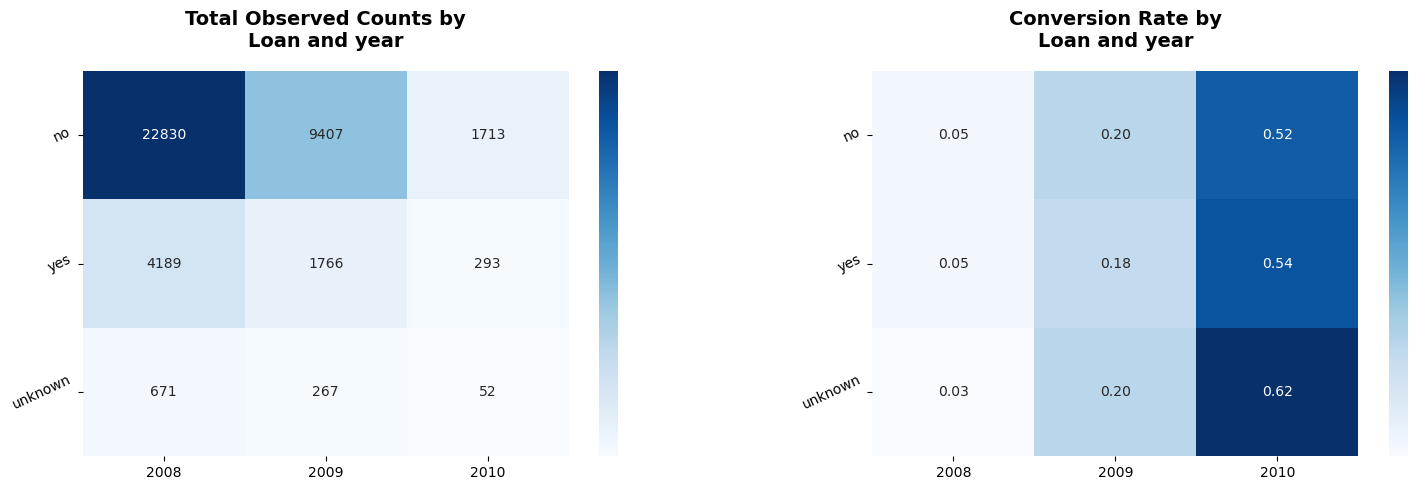

In [44]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
my_file.plot_heatmap_bivariate_analysis(tele_df, 'loan', 'year', 'y_binary', fig=fig, ax=ax);

- Equal chance of subscribing for term deposit with no, yes or unknown personal loan(based on plot of YES-proportion or first plot) but thie trend don't follow for YES-proportion by year (Vased on heatmap plot or second plot).

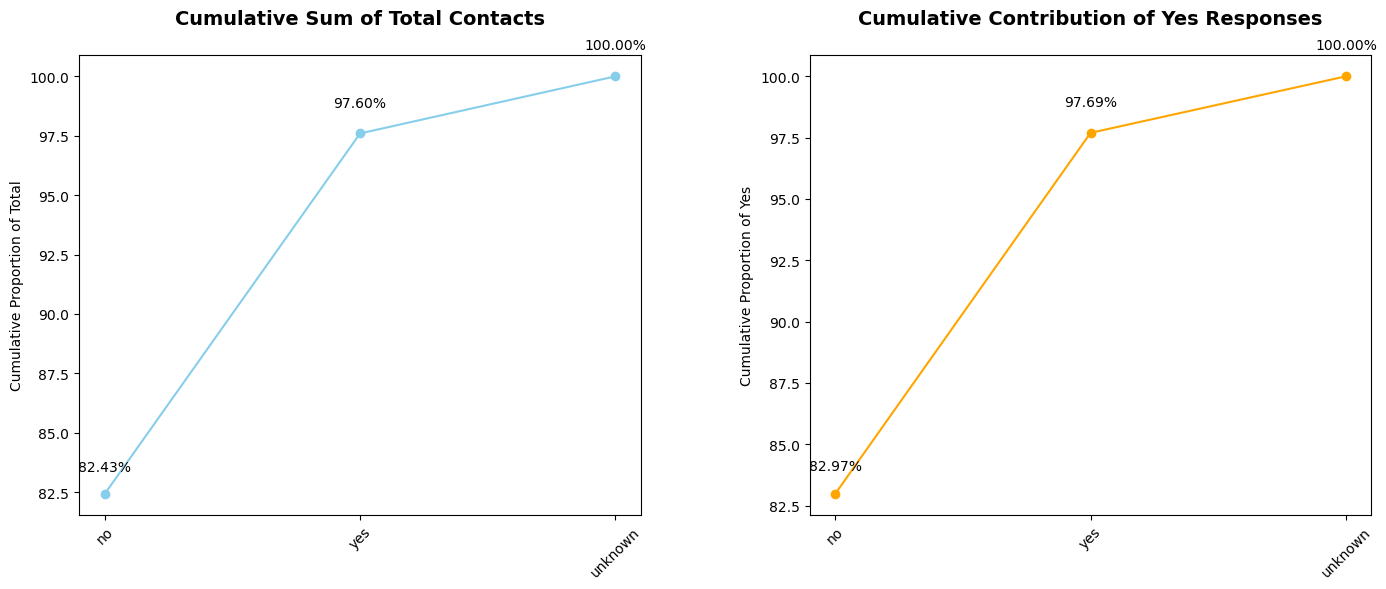

In [45]:
# cumsum of total counts and yes response by loan
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
my_file.plot_cumsum_total_yes_response(loan_counts, 'loan', 'cumsum_total_proportion', 'cumsum_yes_proportion', fig=fig, ax=ax);


In [46]:
# chi-square test between loan and y(term-deposit)
my_file.chi_square_categorical_y(tele_df, 'loan', 'y')

,statistical_values
Chi-square,1.094028
pvalue,0.578675
cramers_v,0.005154
effect_size,small


- **Association between `loan and y` is negligible.**

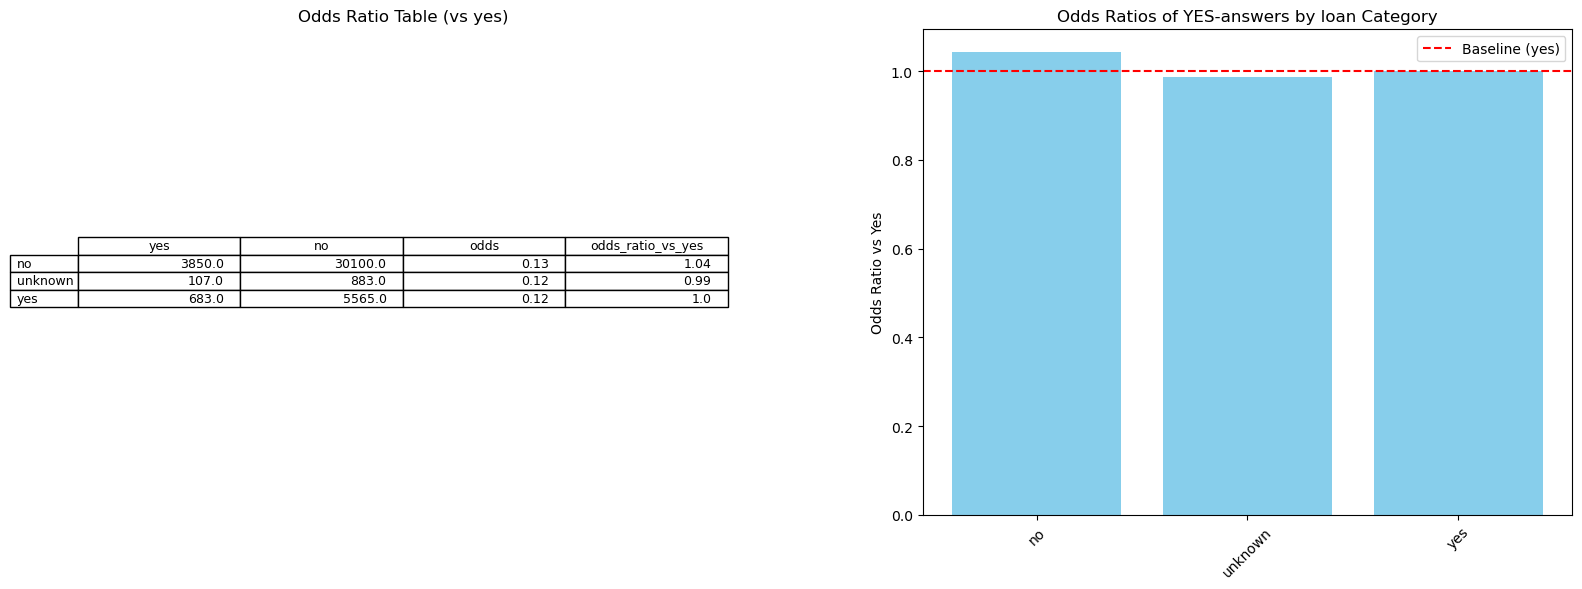

In [47]:
# compute odds ratio between categories
my_file.plot_odd_ratio_table(tele_df, 'loan', 'y', 'yes')

- **Client with no personal loan more likely to subscribe than with personal loan but can't rely on this findings bcoz margin is negligible.**

**Conclusion :**

- During campaign, client with no personal loan(~ 82%) contacted more than with personal loan(~ 15%).
- No substantial evidence of relationships between loan's categories and YES-responses.

**Dimension : `age`**

- What is the distribution of client's age, and how does the term deposit subscription conversion rate vary across different age groups?

**Analyzing Process:**

- **Binning Ages**: We group client ages into bins (e.g., 17–19, 20–24, …).
- Compute the conversion rate (percentage of “yes”) per age group.

- Visualization:
1. An histogram and box plots displays the age distribution.
2. An bar chart shows the conversion rates across age groups.


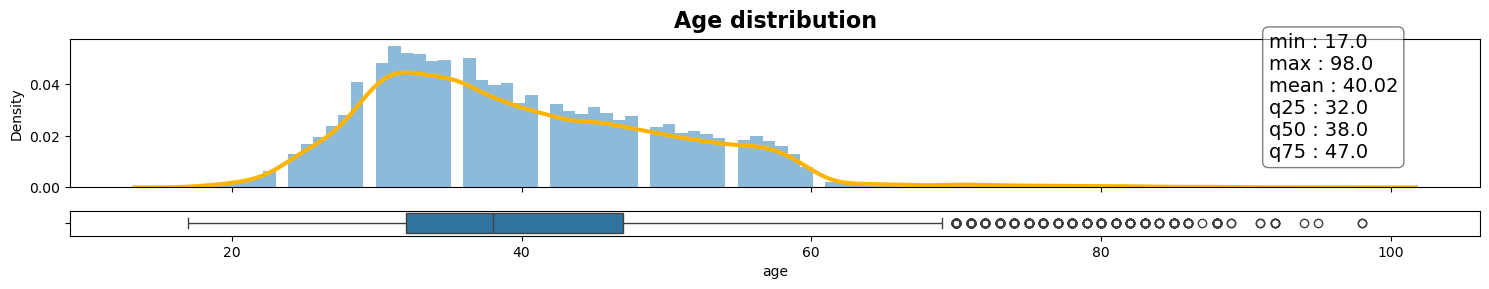

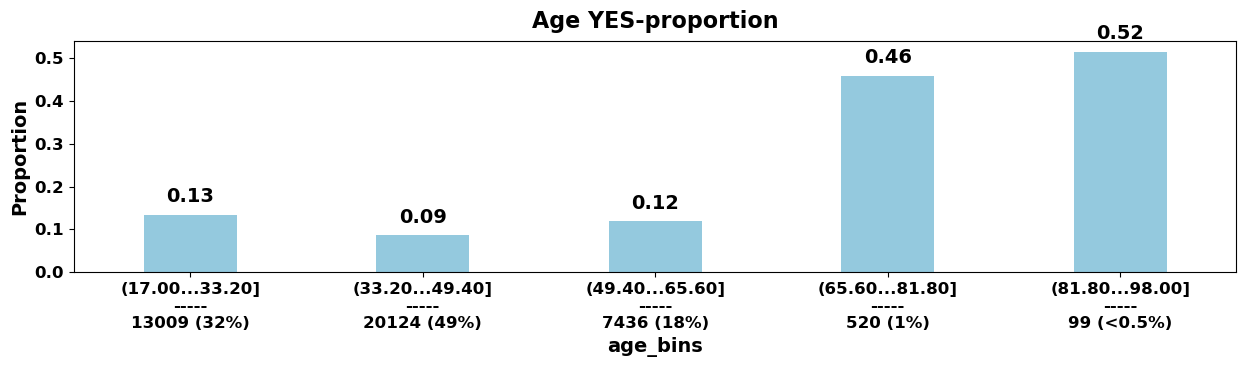

In [48]:
my_file.plot_numeric_distribution(tele_df, 'age')
fig, ax = plt.subplots(figsize=(15, 3))
my_file.plot_numeric_yes_proportion(tele_df, 'age', 'y_binary', 5, 0.4, ax=ax, fig=fig)
plt.show()

In [49]:
# Term Deposit Subscription Conversion Rate by Age Group
import plotly.express as px
min_age = 15
# Round up the maximum age to the nearest multiple of 5
max_age = int(np.ceil(tele_df['age'].max() / 5.0) * 5)
# Create bins with a step of 5 (e.g., 15, 20, 25, ... up to max_age)
bins = np.arange(min_age, max_age + 1, 5)
# Create custom labels for each bin (e.g., "15-19", "20-24", ...)
labels = [f"{b}-{b+4}" for b in bins[:-1]]

# Create a new column 'age_group' using these bins; use right=False so that [15,20) corresponds to 15-19
tele_df['age_group'] = pd.cut(tele_df['age'], bins=bins, labels=labels, right=False, include_lowest=True)

# -------------------------------
# Calculate conversion rate for each age group
# -------------------------------
# Group by the new age_group and compute the total number of clients and number of "yes" responses
group_stats = tele_df.groupby('age_group', observed=True)['y'].agg(
    total='count',
    yes=lambda x: (x == 'yes').sum()
).reset_index()

# Calculate conversion rate (percentage)
group_stats['conversion_rate'] = (group_stats['yes'] / group_stats['total']) * 100

# -------------------------------
# Create an Interactive Bar Chart with Borders and Annotations
# -------------------------------
fig = px.bar(
    group_stats,
    x='age_group',
    y='conversion_rate',
    title='Conversion Rate by Age Group',
    labels={'age_group': 'Age Group', 'conversion_rate': 'Conversion Rate (%)'},
    template='plotly_white'
)

# Add a black border around each bar
fig.update_traces(marker_line_color='black', marker_line_width=1)

# Annotate each bar with the conversion rate percentage
for _, row in group_stats.iterrows():
    if row['total'] > 0:
        fig.add_annotation(
            x=row['age_group'],
            y=row['conversion_rate'] + 1,  # Adjust vertical offset as needed
            text=f"{row['conversion_rate']:.1f}%",
            showarrow=False,
            font=dict(color="black", size=10)
        )

# Update layout to add borders to the axes and adjust margins
fig.update_layout(
    plot_bgcolor='white',
    xaxis=dict(showline=True, linewidth=1, linecolor='black'),
    yaxis=dict(showline=True, linewidth=1, linecolor='black'),
    margin=dict(l=50, r=50, t=50, b=50)
)

# Display the interactive chart
fig.show()

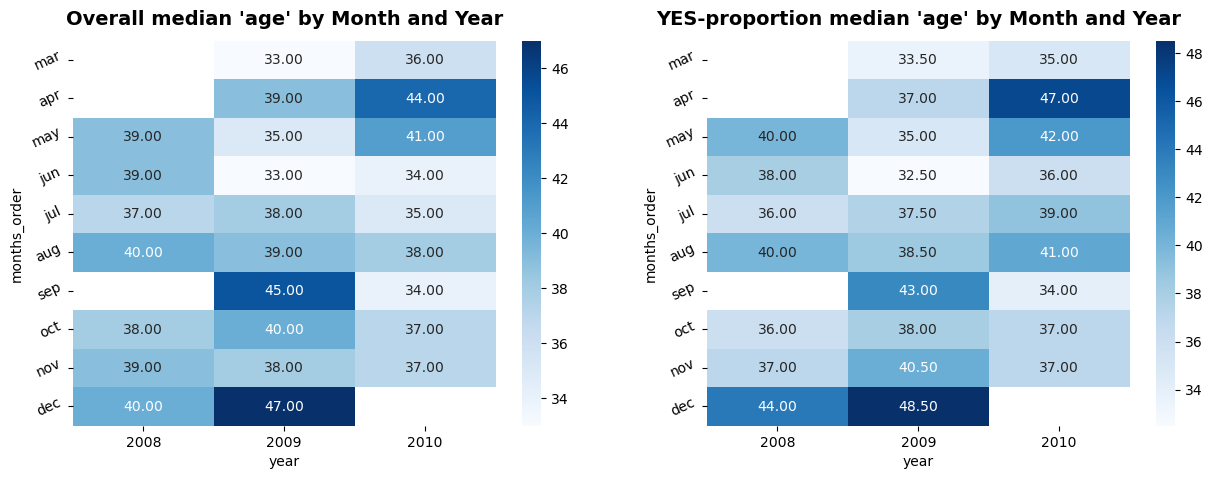

In [50]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
my_file.plot_numeric_heatmap_bivariate_analysis(tele_df, 'months_order', 'year', 'age', 'month', fig=fig, ax=ax);

In [51]:
feature_name = 'age'
print(f'Pearson corr. coef. ({feature_name} vs y): {tele_df[feature_name].corr(tele_df["y_binary"]):.4f}')

Pearson corr. coef. (age vs y): 0.0304


- There is no correlation between `age and y`.

**Conclusions:**

- Median age: 38 year.
- Mean age: ~ 40 year
- Client older than 65 years are more likely to agree to subscribe a bank term deposit can't rely upon this finding bcoz data is not sufficient, but in general, there is no correlation between the age and YES-proportion.
